# Solar Flare Prediction: Baseline Modeling

This notebook is the second stage of the project. It takes the labeled active-region dataset and trains a few baseline classifiers for predicting whether an active region will produce a flare in the next 24 hours.


## Modeling Strategy

- Use SHARP magnetic features as predictors.
- Use the binary target `flare_next_24h`.
- Start with simple baselines: logistic regression, decision tree, and random forest.
- Compare models using precision, recall, F1 score, ROC AUC, and average precision.

This is a baseline stage, not the final forecasting system. A later version could use longer time windows, larger historical coverage, and temporal validation.


In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.modeling import (
    plot_confusion_matrix,
    plot_feature_importance,
    plot_model_comparison,
    split_features_and_labels,
    train_baseline_models,
    evaluate_models,
)
from src.preprocessing import prepare_modeling_dataset

pd.set_option('display.max_columns', 50)


## Load the Labeled Dataset

This notebook uses the same downloaded NOAA flare reports and SHARP parameter table created during stage one.


In [2]:
flare_files = sorted((PROJECT_ROOT / 'data' / 'noaa_flare_reports').glob('*.txt'))
sharp_file = PROJECT_ROOT / 'data' / 'sharp_parameters.csv'

flare_df, active_df, labeled_df = prepare_modeling_dataset(flare_files, sharp_file)
print('Samples:', len(labeled_df))
print('Positive labels:', int(labeled_df['flare_next_24h'].sum()))
print('Positive rate:', round(labeled_df['flare_next_24h'].mean(), 3))


Samples: 208
Positive labels: 31
Positive rate: 0.149


In [3]:
X_train, X_test, y_train, y_test, feature_columns = split_features_and_labels(labeled_df, test_size=0.3)

print('Training samples:', len(X_train))
print('Test samples:', len(X_test))
print('Features:', feature_columns)


Training samples: 145
Test samples: 63
Features: ['USFLUX', 'AREA_ACR', 'TOTUSJH', 'TOTUSJZ', 'ABSNJZH', 'SAVNCPP', 'MEANPOT', 'R_VALUE', 'MEANGBT', 'MEANGBZ', 'MEANGBH']


## Train Baseline Models


In [4]:
models = train_baseline_models(X_train, y_train, feature_columns)
results_df = evaluate_models(models, X_test, y_test)
results_df


,model,accuracy,precision,recall,f1,average_precision,roc_auc
0,Logistic Regression,0.857143,0.500000,0.666667,0.571429,0.703885,0.908436
1,Random Forest,0.873016,0.555556,0.555556,0.555556,0.681610,0.898148
2,Decision Tree,0.777778,0.352941,0.666667,0.461538,0.497946,0.772634


## Model Comparison Figure


In [5]:
comparison_path = plot_model_comparison(results_df, PROJECT_ROOT / 'figures')
comparison_path


WindowsPath('C:/Users/stude/OneDrive/Desktop/Projects/Solar Flare Prediction/solar_flare_prediction/figures/baseline_model_comparison.png')

## Inspect the Best Model

For a first baseline, the random forest is usually a reasonable choice because it can capture nonlinear relationships without requiring heavy tuning.


In [6]:
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]

confusion_path = plot_confusion_matrix(best_model, X_test, y_test, PROJECT_ROOT / 'figures', best_model_name)
importance_path = plot_feature_importance(best_model, feature_columns, PROJECT_ROOT / 'figures', best_model_name)

print('Best model:', best_model_name)
print('Confusion matrix:', confusion_path)
print('Feature importance:', importance_path)


Best model: Logistic Regression
Confusion matrix: C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\logistic_regression_confusion_matrix.png
Feature importance: C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\logistic_regression_feature_importance.png


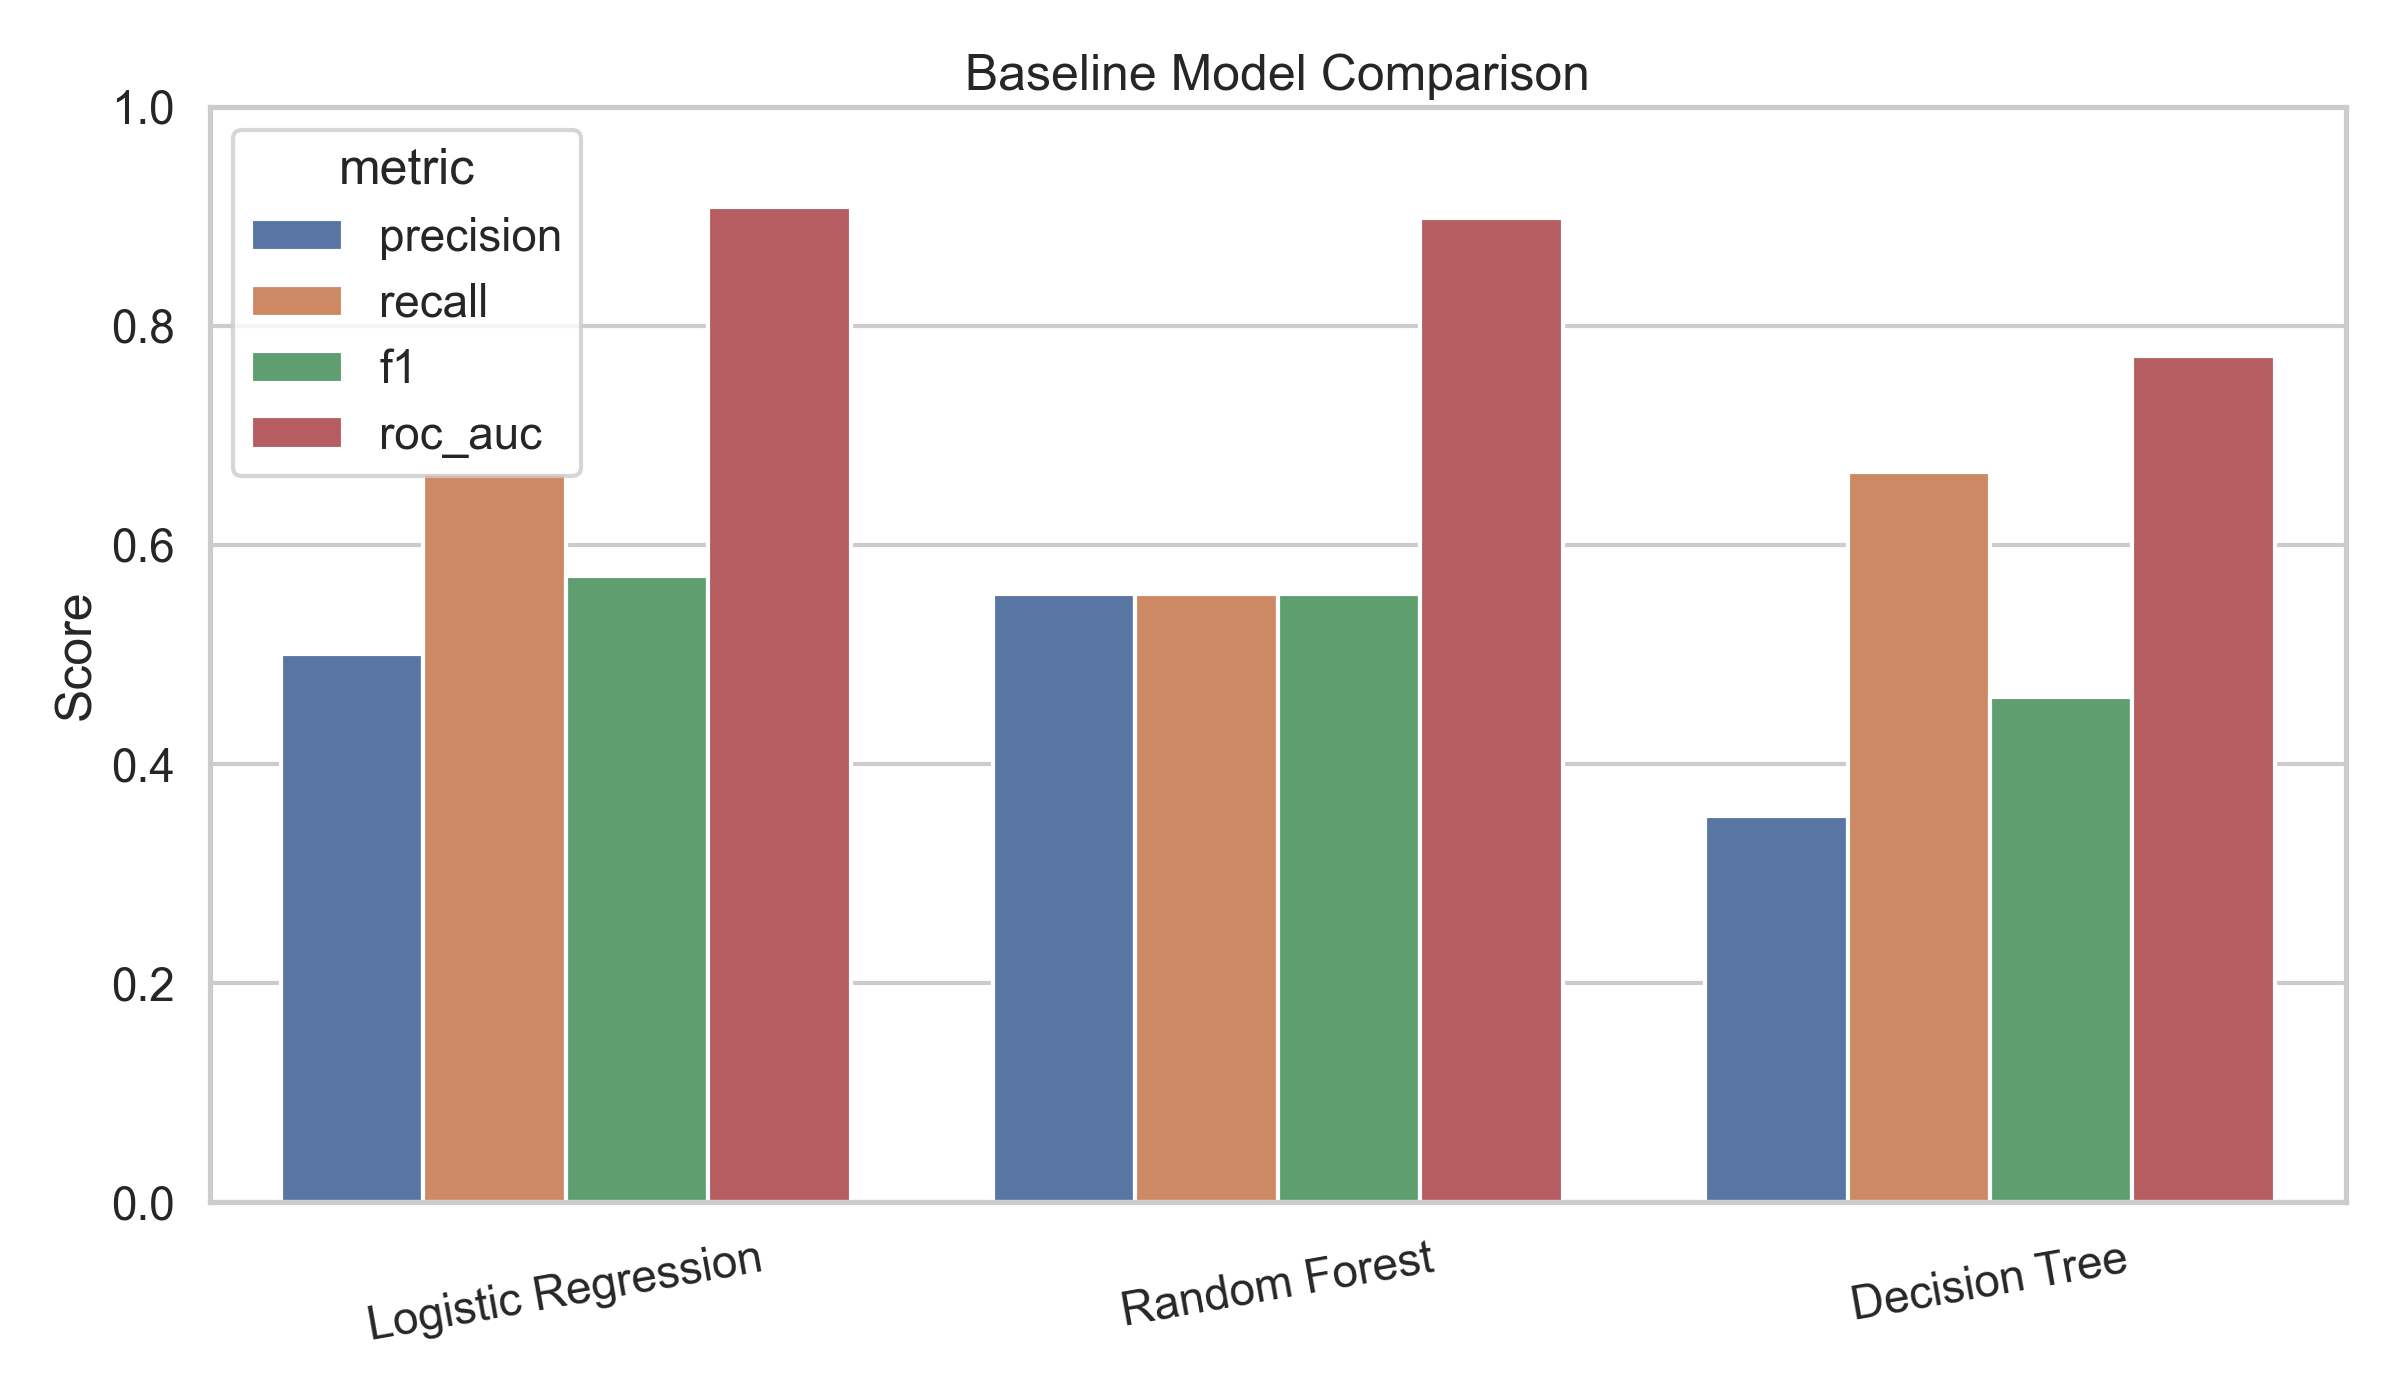

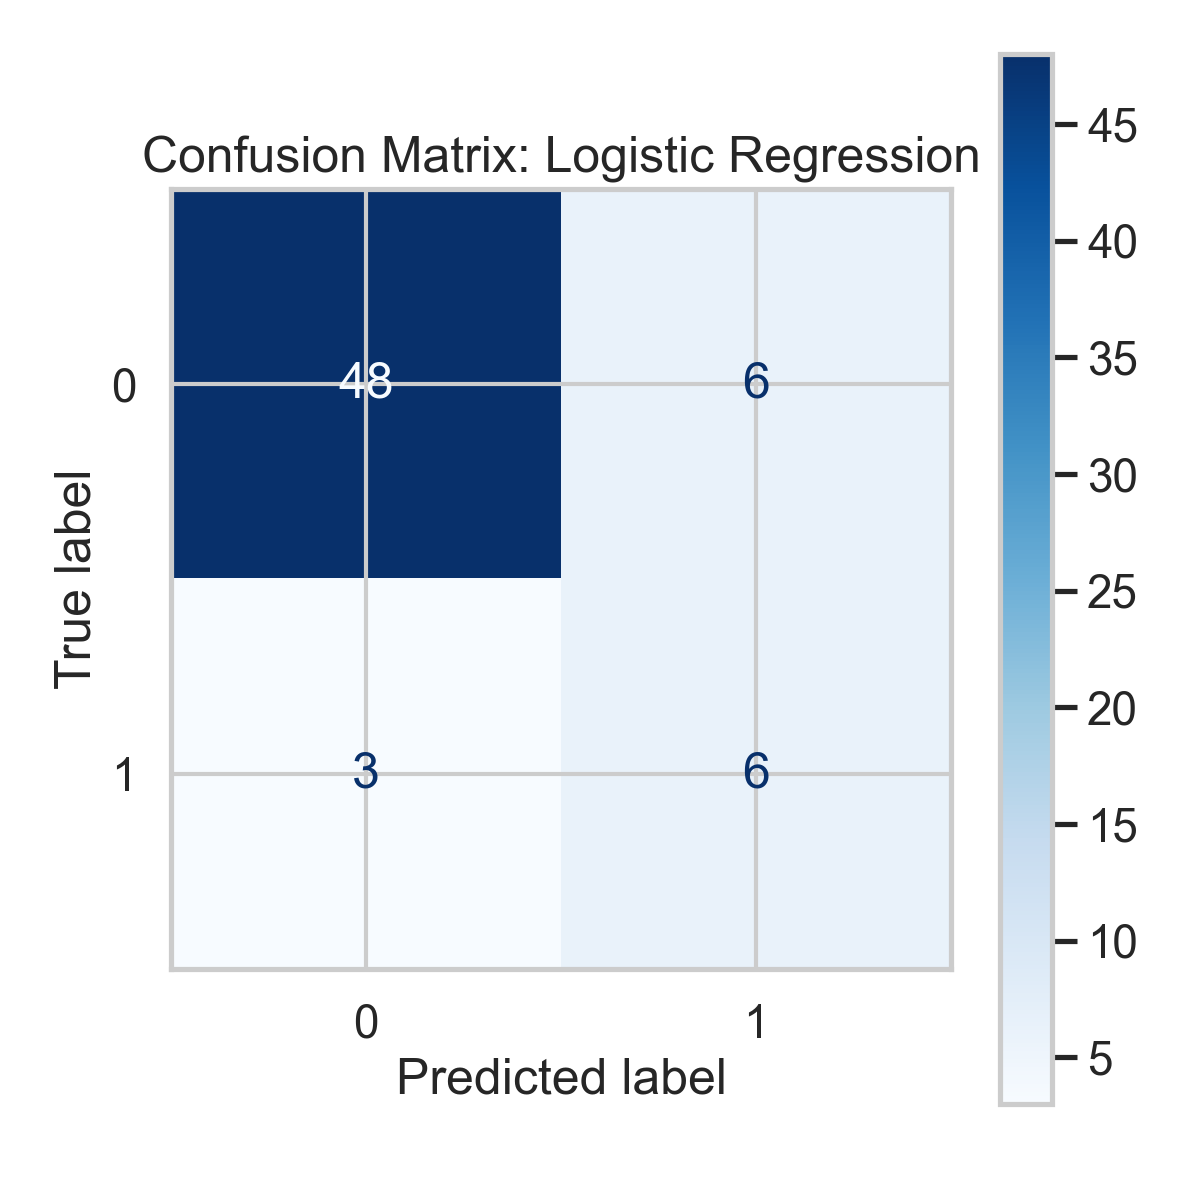

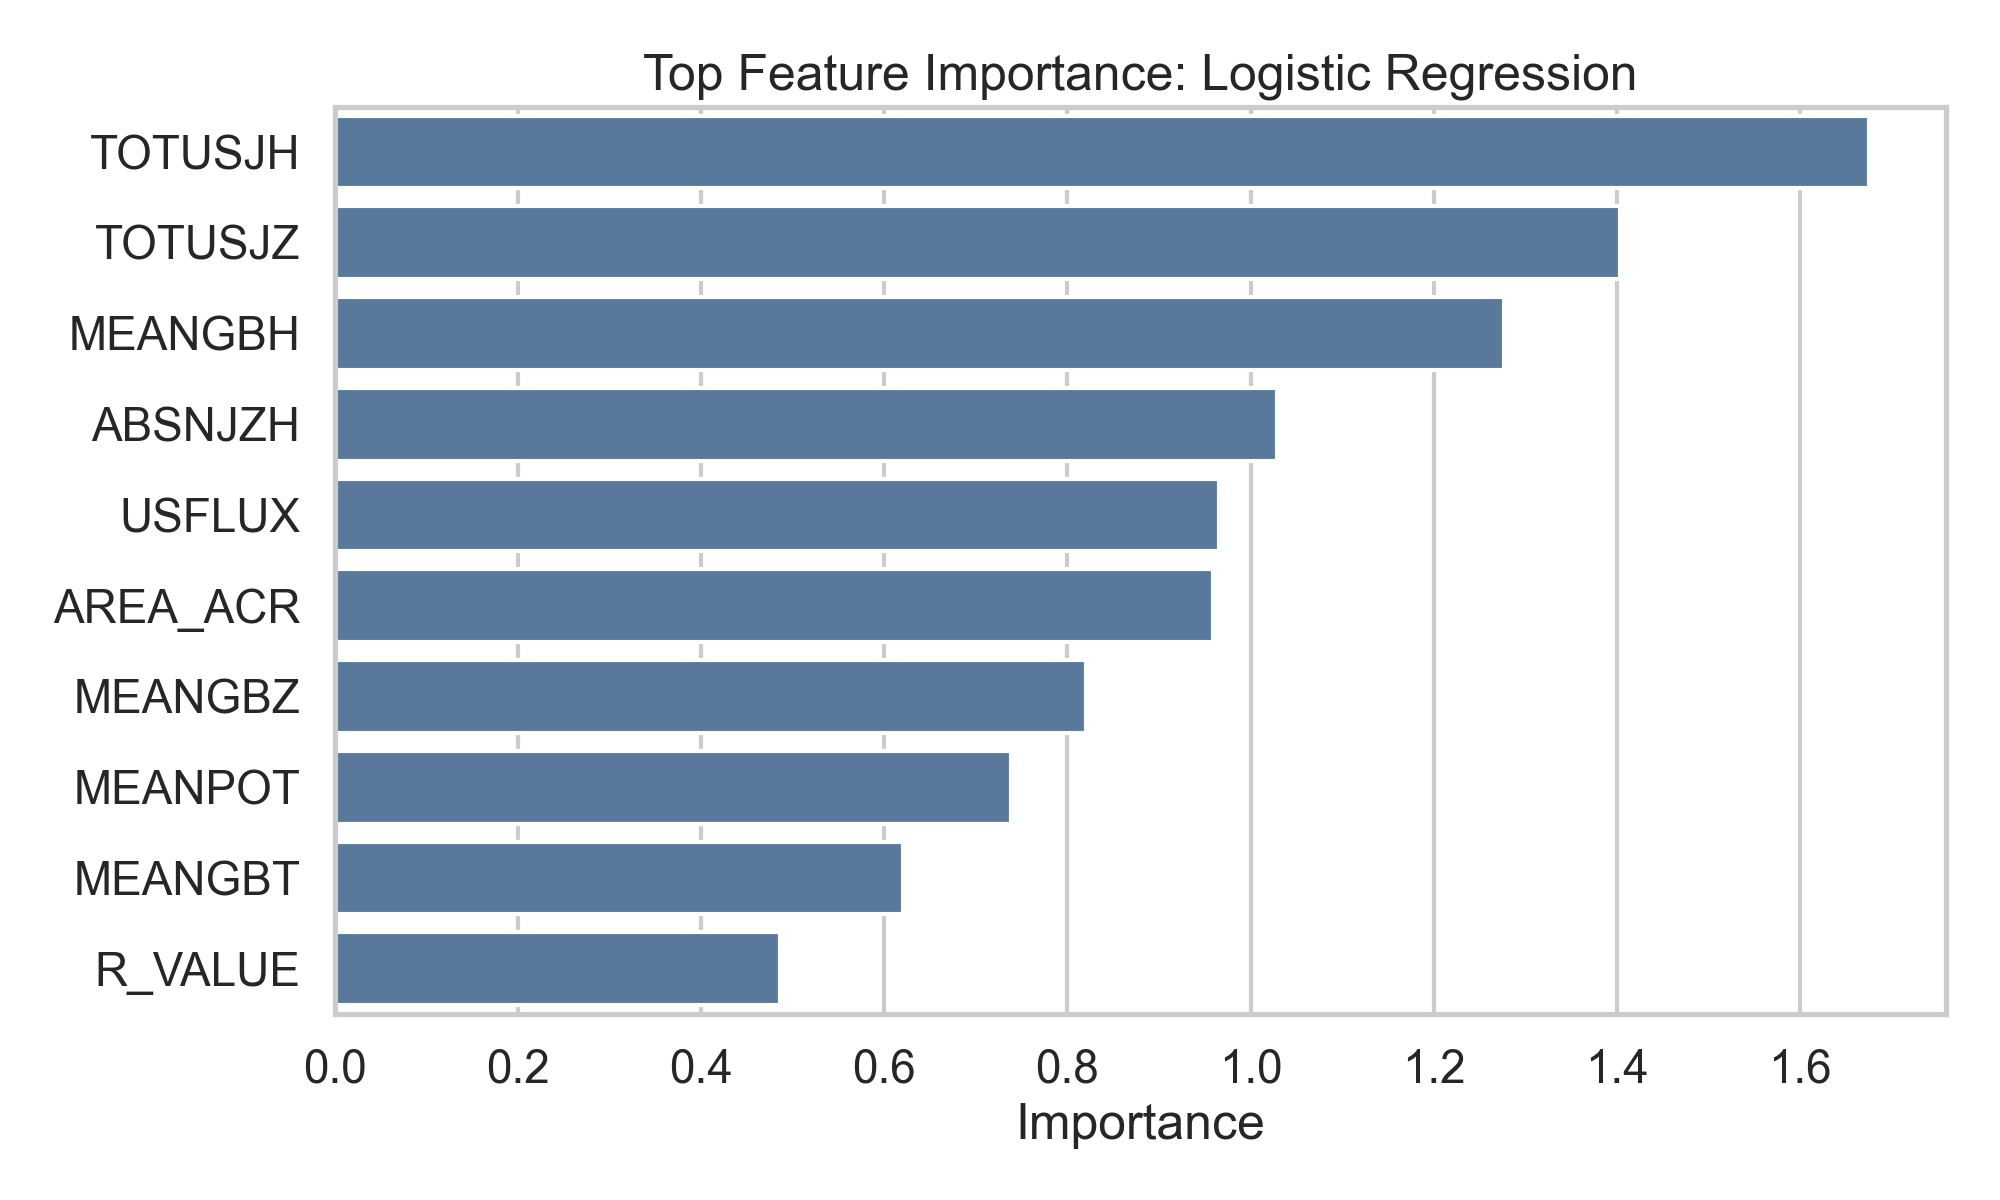

In [7]:
from IPython.display import Image, display

display(Image(filename=str(comparison_path)))
display(Image(filename=str(confusion_path)))
display(Image(filename=str(importance_path)))


## Interpretation

At this stage, the purpose is not to claim a final forecasting model. The purpose is to check whether the active-region magnetic features contain usable predictive signal. If the stronger magnetic complexity variables repeatedly rank near the top, that supports moving into a more serious modeling stage with larger datasets and more careful validation.
